In [1]:
import pandas as pd

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(
    "/kaggle/input/datasets/lfreedom2750/coffee-price-dataset/llm_combined/volatility_robusta_generated_llm_features.csv"
)

# =========================
# TIME SORT
# =========================
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# =========================
# DROP NA (lag/rolling features)
# =========================
df = df.dropna().reset_index(drop=True)

# =========================
# SPLIT X / y
# =========================
X = df.drop(columns=["volatility_price", "date"])
y = df["volatility_price"]

# =========================
# TIME-BASED SPLIT (BY DATE)
# =========================
train_end = "2025-03-28"

train_mask = df["date"] <= train_end

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[~train_mask]
y_test = y[~train_mask]

# =========================
# CHECK
# =========================
print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("Train end date:", train_end)

Train: (466, 115)
Test : (239, 115)
Train end date: 2025-03-28


In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# CROSS VALIDATION
# =========================
tscv = TimeSeriesSplit(n_splits=5)

# =========================
# HYPERPARAMETER GRID
# =========================
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# =========================
# MODEL
# =========================
rf_model = RandomForestRegressor(random_state=42)

# =========================
# GRID SEARCH
# =========================
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
rf_grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================
best_rf = rf_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, "best_random_forest.pkl")

joblib.dump(best_rf, checkpoint_path)

print(f"Model saved to: {checkpoint_path}")

# =========================
# PREDICTION
# =========================
pred_rf = best_rf.predict(X_test)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_rf)
mse = mean_squared_error(y_test, pred_rf)
rmse = np.sqrt(mse)

print("Best Params:", rf_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Model saved to: checkpoints/best_random_forest.pkl
Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
MAE  : 2426.9898
MSE  : 9571747.7979
RMSE : 3093.8241


                 Feature  Importance
28           roll_std_60    0.071840
24           roll_std_20    0.070287
43             hl_spread    0.059657
39            return_20d    0.044250
31                rsi_14    0.039141
..                   ...         ...
114  SIG_HIGH_CONFIDENCE    0.000186
110     SIG_SPLIT_SIGNAL    0.000174
68         pct_high_cert    0.000050
108          SIG_BEARISH    0.000022
112    SIG_MANY_ARTICLES    0.000000

[115 rows x 2 columns]


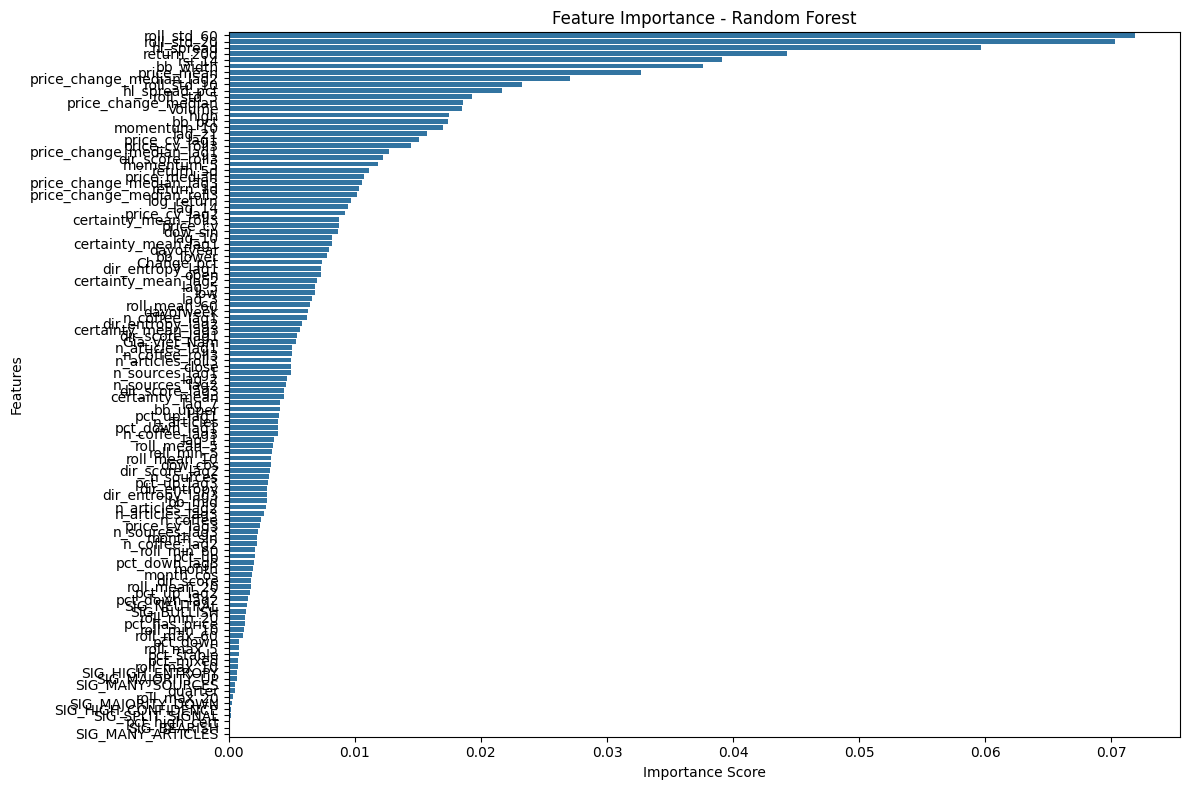

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# FEATURE IMPORTANCE
# =========================
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

# Sắp xếp giảm dần
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# In bảng
print(feature_importance)

# =========================
# VISUALIZATION
# =========================
plt.figure(figsize=(12, 8))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

test_dates : 239
y_test     : 239
pred_rf    : 239


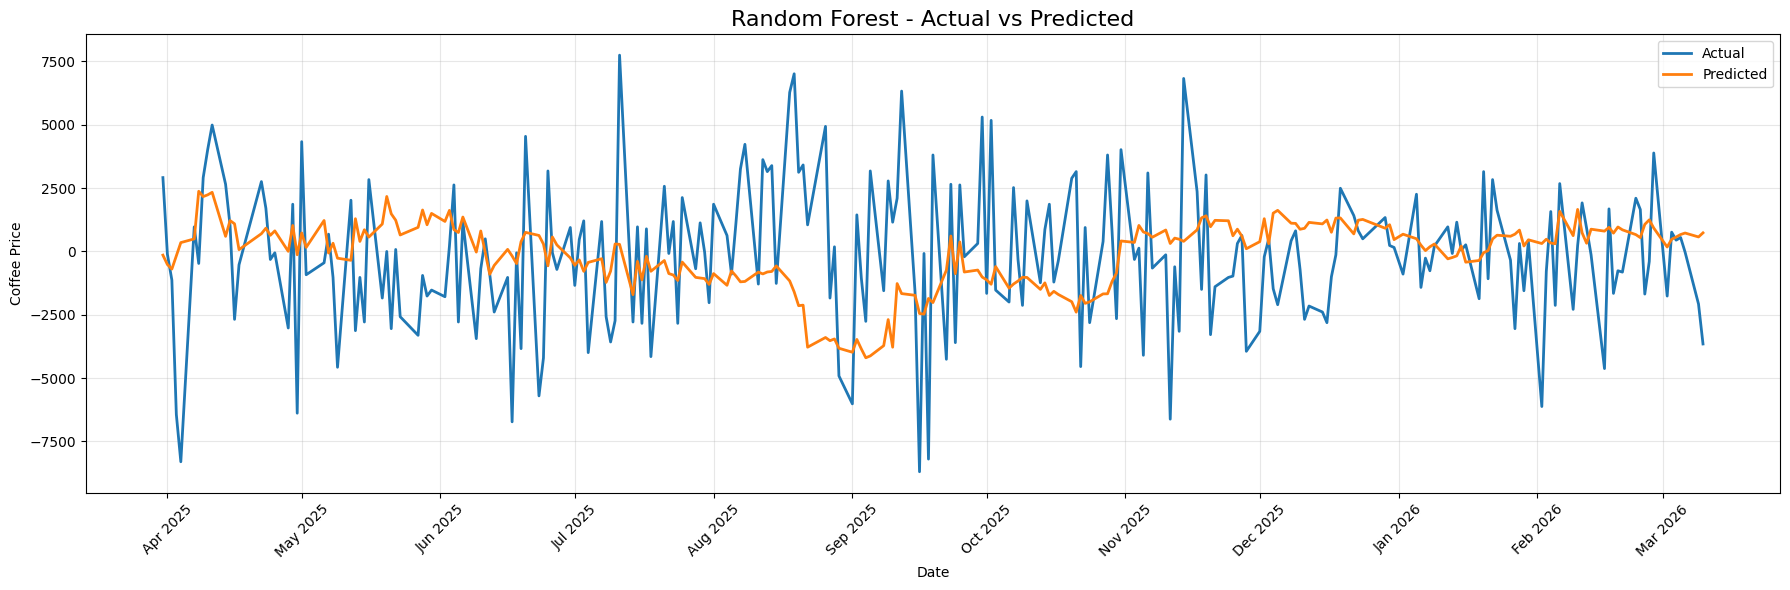

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# TEST DATES
# =========================
test_dates = df.loc[
    ~train_mask,
    "date"
].reset_index(drop=True)

# =========================
# CHECK LENGTH
# =========================
print("test_dates :", len(test_dates))
print("y_test     :", len(y_test))
print("pred_rf    :", len(pred_rf))

# =========================
# PLOT
# =========================
plt.figure(figsize=(18, 6))

# Actual
plt.plot(
    test_dates,
    y_test.reset_index(drop=True),
    label="Actual",
    linewidth=2
)

# Predicted
plt.plot(
    test_dates,
    pred_rf,
    label="Predicted",
    linewidth=2
)

# =========================
# DATE FORMAT
# =========================
ax = plt.gca()

# Hiện mỗi tháng
ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

# Format tháng/năm
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

# =========================
# STYLE
# =========================
plt.title(
    "Random Forest - Actual vs Predicted",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [5]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# HYPERPARAMETER GRID
# =========================
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

# =========================
# MODEL
# =========================
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
xgb_grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================
best_xgb = xgb_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, "best_xgboost.pkl")

joblib.dump(best_xgb, checkpoint_path)

print(f"Model saved to: {checkpoint_path}")

# =========================
# PREDICTION
# =========================
pred_xgb = best_xgb.predict(X_test)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_xgb)
mse = mean_squared_error(y_test, pred_xgb)
rmse = np.sqrt(mse)

print("Best Params:", xgb_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model saved to: checkpoints/best_xgboost.pkl
Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
MAE  : 2213.6857
MSE  : 8180769.6523
RMSE : 2860.2045


                 Feature  Importance
43             hl_spread    0.034359
44         hl_spread_pct    0.033976
62          price_median    0.025195
46                 month    0.025187
63            price_mean    0.024993
..                   ...         ...
110     SIG_SPLIT_SIGNAL    0.000000
111     SIG_HIGH_ENTROPY    0.000000
112    SIG_MANY_ARTICLES    0.000000
113     SIG_MANY_SOURCES    0.000000
114  SIG_HIGH_CONFIDENCE    0.000000

[115 rows x 2 columns]


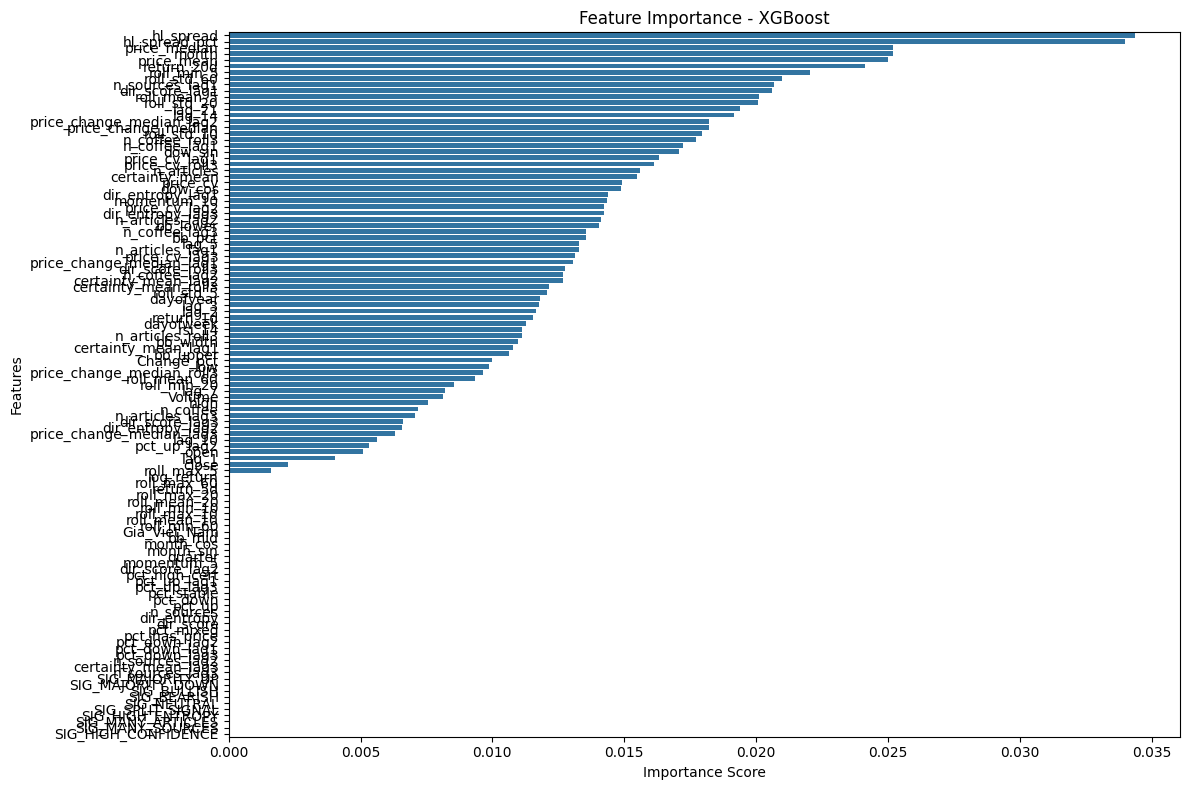

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# FEATURE IMPORTANCE
# =========================
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

# Sắp xếp giảm dần
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# In bảng
print(feature_importance)

# =========================
# VISUALIZATION
# =========================
plt.figure(figsize=(12, 8))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

test_dates : 239
y_test     : 239
pred_xgb   : 239


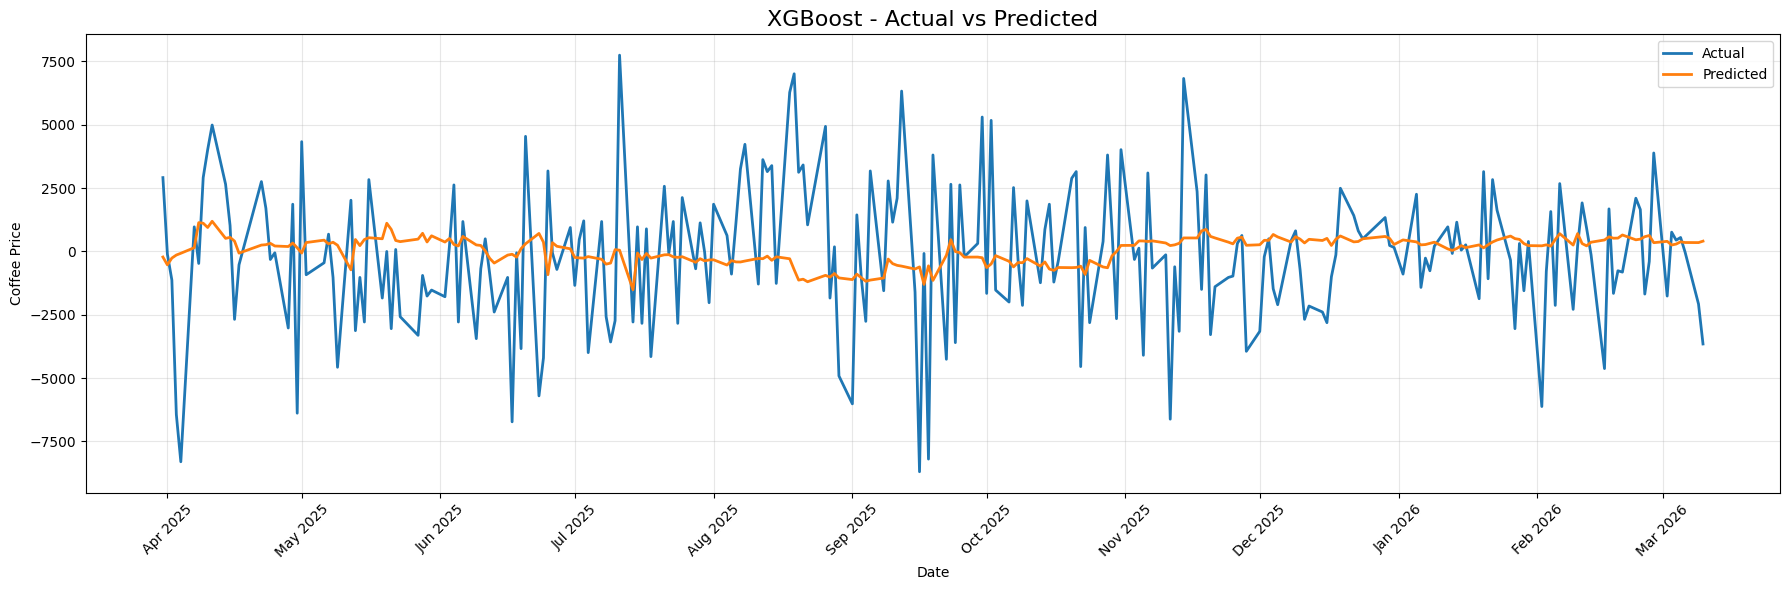

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# TEST DATES
# =========================
test_dates = df.loc[
    ~train_mask,
    "date"
].reset_index(drop=True)

# =========================
# CHECK LENGTH
# =========================
print("test_dates :", len(test_dates))
print("y_test     :", len(y_test))
print("pred_xgb   :", len(pred_xgb))

# =========================
# PLOT
# =========================
plt.figure(figsize=(18, 6))

# Actual
plt.plot(
    test_dates,
    y_test.reset_index(drop=True),
    label="Actual",
    linewidth=2
)

# Predicted
plt.plot(
    test_dates,
    pred_xgb,
    label="Predicted",
    linewidth=2
)

# =========================
# DATE FORMAT
# =========================
ax = plt.gca()

# Hiện mỗi tháng
ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

# Format tháng/năm
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

# =========================
# STYLE
# =========================
plt.title(
    "XGBoost - Actual vs Predicted",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [8]:
# =========================
# CELL 3 — LIGHTGBM
# =========================

from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

# =========================
# HYPERPARAMETER GRID
# =========================
lgbm_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, -1],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50]
}

# =========================
# MODEL
# =========================
lgbm_model = LGBMRegressor(
    random_state=42,
    verbose=-1
)

# =========================
# GRID SEARCH
# =========================
lgbm_grid = GridSearchCV(
    estimator=lgbm_model,
    param_grid=lgbm_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0
)

# =========================
# TRAINING
# =========================
lgbm_grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================
best_lgbm = lgbm_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(
    checkpoint_dir,
    "best_lightgbm.pkl"
)

joblib.dump(best_lgbm, checkpoint_path)

print(f"Model saved to: {checkpoint_path}")

# =========================
# PREDICTION
# =========================
pred_lgbm = best_lgbm.predict(X_test)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_lgbm)
mse = mean_squared_error(y_test, pred_lgbm)
rmse = np.sqrt(mse)

print("\n===== LIGHTGBM RESULTS =====")
print("Best Params:", lgbm_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Model saved to: checkpoints/best_lightgbm.pkl

===== LIGHTGBM RESULTS =====
Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'num_leaves': 31}
MAE  : 2205.9162
MSE  : 8062394.3709
RMSE : 2839.4356


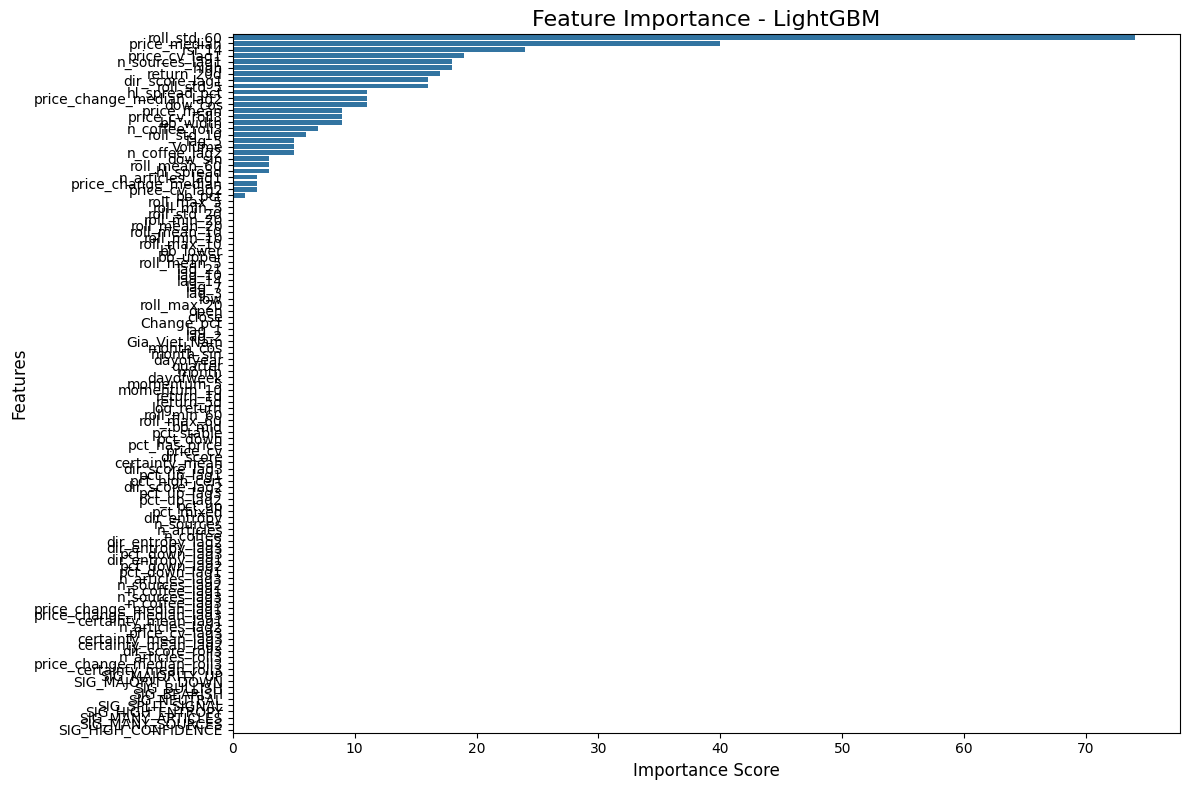

In [9]:
# =========================
# CELL — LIGHTGBM FEATURE IMPORTANCE
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# CREATE IMPORTANCE DATAFRAME
# =========================
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_lgbm.feature_importances_
})

# =========================
# SORT FEATURES
# =========================
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# =========================
# PLOT ALL FEATURES
# =========================
plt.figure(figsize=(12, 8))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance - LightGBM",
    fontsize=16
)

plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

test_dates : 239
y_test     : 239
pred_lgbm  : 239


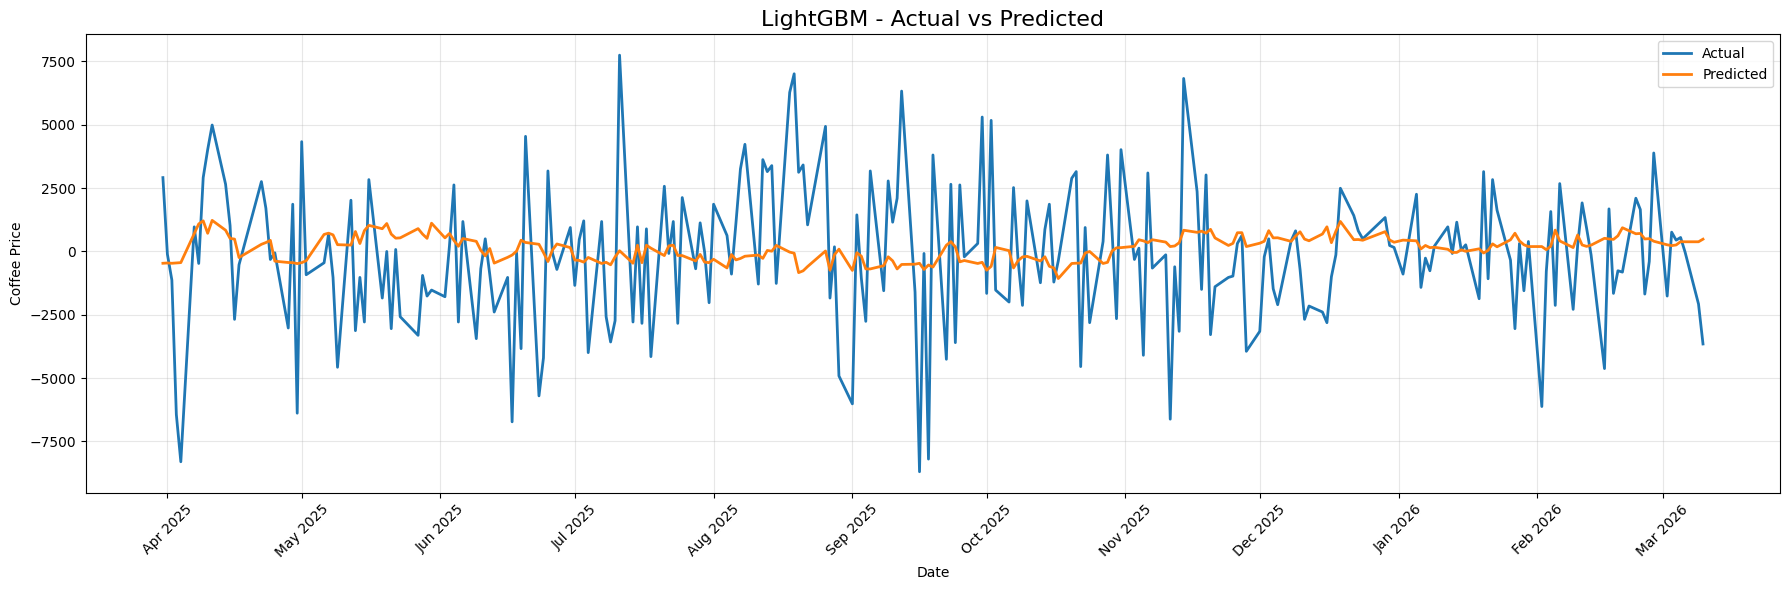

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# TEST DATES
# =========================
test_dates = df.loc[
    ~train_mask,
    "date"
].reset_index(drop=True)

# =========================
# CHECK LENGTH
# =========================
print("test_dates :", len(test_dates))
print("y_test     :", len(y_test))
print("pred_lgbm  :", len(pred_lgbm))

# =========================
# PLOT
# =========================
plt.figure(figsize=(18, 6))

# Actual
plt.plot(
    test_dates,
    y_test.reset_index(drop=True),
    label="Actual",
    linewidth=2
)

# Predicted
plt.plot(
    test_dates,
    pred_lgbm,
    label="Predicted",
    linewidth=2
)

# =========================
# DATE FORMAT
# =========================
ax = plt.gca()

# Hiện mỗi tháng
ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

# Format tháng/năm
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

# =========================
# STYLE
# =========================
plt.title(
    "LightGBM - Actual vs Predicted",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [11]:
# =========================
# CELL 4 — CATBOOST
# =========================

from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# HYPERPARAMETER GRID
# =========================
cat_params = {
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "iterations": [100, 200]
}

# =========================
# MODEL
# =========================
cat_model = CatBoostRegressor(
    verbose=0,
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
cat_grid = GridSearchCV(
    estimator=cat_model,
    param_grid=cat_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
cat_grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================
best_cat = cat_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, "best_catboost.pkl")

joblib.dump(best_cat, checkpoint_path)

print(f"Model saved to: {checkpoint_path}")

# =========================
# PREDICTION
# =========================
pred_cat = best_cat.predict(X_test)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_cat)
mse = mean_squared_error(y_test, pred_cat)
rmse = np.sqrt(mse)

print("Best Params:", cat_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Model saved to: checkpoints/best_catboost.pkl
Best Params: {'depth': 6, 'iterations': 100, 'learning_rate': 0.01}
MAE  : 2162.0669
MSE  : 7851471.1673
RMSE : 2802.0477


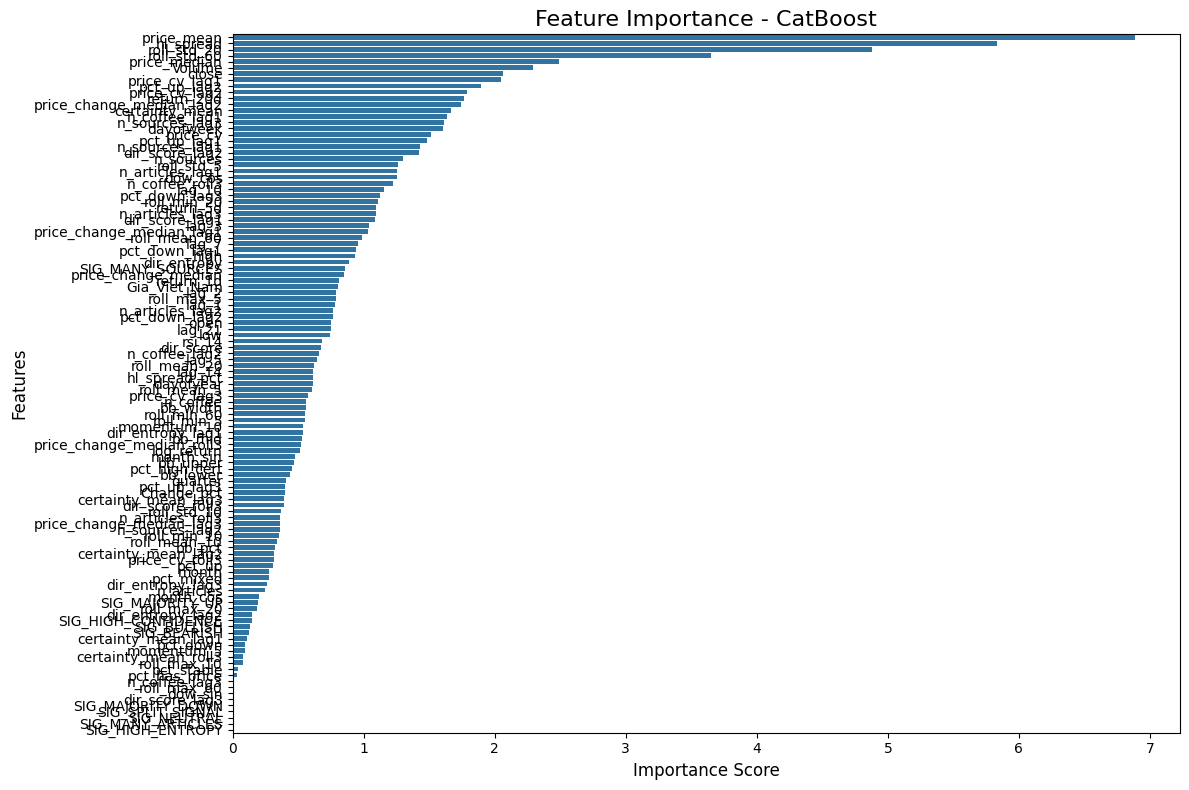

In [12]:
# =========================
# CELL — CATBOOST FEATURE IMPORTANCE
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# CREATE IMPORTANCE DATAFRAME
# =========================
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_cat.feature_importances_
})

# =========================
# SORT FEATURES
# =========================
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# =========================
# PLOT ALL FEATURES
# =========================
plt.figure(figsize=(12, 8))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance - CatBoost",
    fontsize=16
)

plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

test_dates : 239
y_test     : 239
pred_cat   : 239


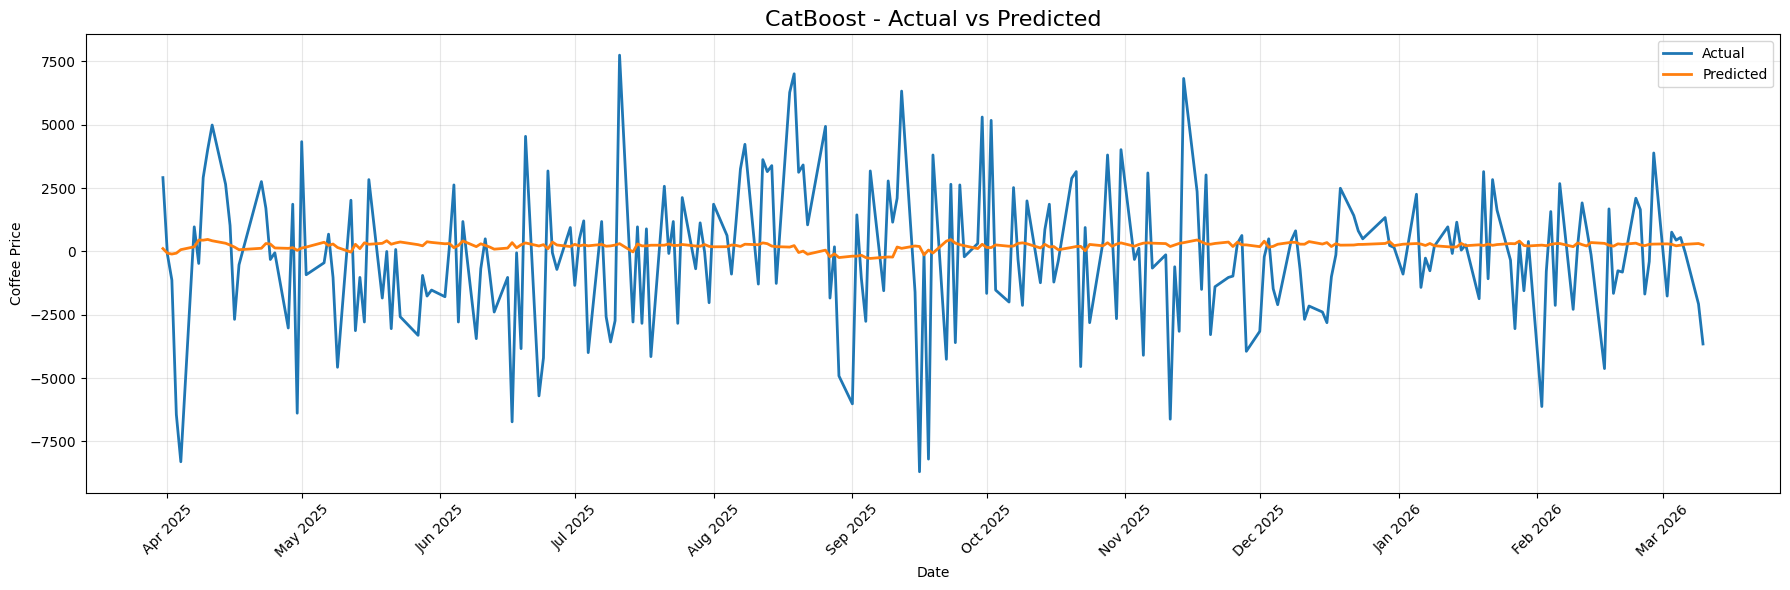

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# TEST DATES
# =========================
test_dates = df.loc[
    ~train_mask,
    "date"
].reset_index(drop=True)

# =========================
# CHECK LENGTH
# =========================
print("test_dates :", len(test_dates))
print("y_test     :", len(y_test))
print("pred_cat   :", len(pred_cat))

# =========================
# PLOT
# =========================
plt.figure(figsize=(18, 6))

# Actual
plt.plot(
    test_dates,
    y_test.reset_index(drop=True),
    label="Actual",
    linewidth=2
)

# Predicted
plt.plot(
    test_dates,
    pred_cat,
    label="Predicted",
    linewidth=2
)

# =========================
# DATE FORMAT
# =========================
ax = plt.gca()

# Hiện mỗi tháng
ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

# Format tháng/năm
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

# =========================
# STYLE
# =========================
plt.title(
    "CatBoost - Actual vs Predicted",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [14]:
# =========================
# CELL 5 — LASSO
# =========================

from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib
import os

# =========================
# SCALE DATA
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# HYPERPARAMETER GRID
# =========================
lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]
}

# =========================
# MODEL
# =========================
lasso_model = Lasso(
    max_iter=10000,
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
lasso_grid = GridSearchCV(
    estimator=lasso_model,
    param_grid=lasso_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
lasso_grid.fit(X_train_scaled, y_train)

# =========================
# BEST MODEL
# =========================
best_lasso = lasso_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save model
model_path = os.path.join(checkpoint_dir, "best_lasso.pkl")
joblib.dump(best_lasso, model_path)

# Save scaler
scaler_path = os.path.join(checkpoint_dir, "lasso_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

# =========================
# PREDICTION
# =========================
pred_lasso = best_lasso.predict(X_test_scaled)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_lasso)
mse = mean_squared_error(y_test, pred_lasso)
rmse = np.sqrt(mse)

print("Best Params:", lasso_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.365e+05, tolerance: 1.031e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.337e+07, tolerance: 2.362e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.431e+08, tolerance: 5.769e

Model saved to: checkpoints/best_lasso.pkl
Scaler saved to: checkpoints/lasso_scaler.pkl
Best Params: {'alpha': 1.0}
MAE  : 2641.7882
MSE  : 11145218.7641
RMSE : 3338.4456


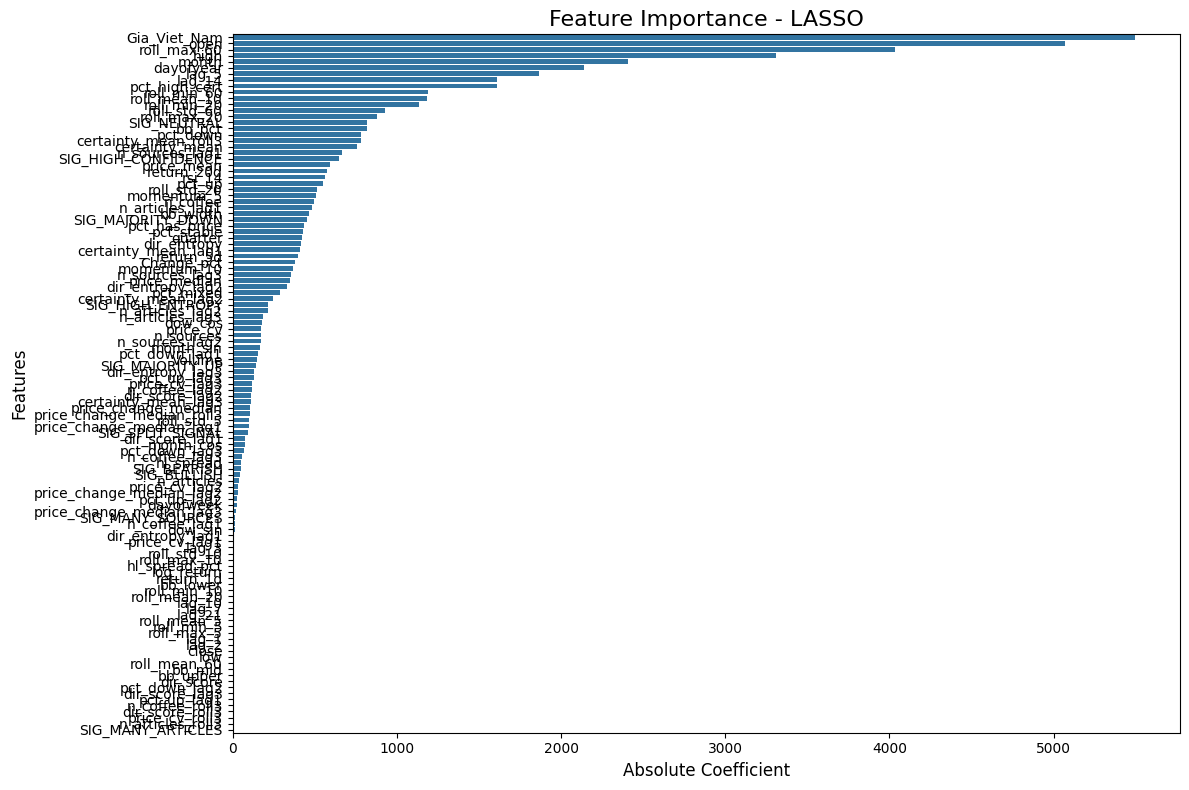

In [15]:
# =========================
# CELL — LASSO FEATURE IMPORTANCE
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# CREATE COEFFICIENT DATAFRAME
# =========================
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_lasso.coef_
})

# =========================
# ABSOLUTE IMPORTANCE
# =========================
coef_df["Abs_Coefficient"] = np.abs(
    coef_df["Coefficient"]
)

# =========================
# SORT FEATURES
# =========================
coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

# =========================
# PLOT ALL FEATURES
# =========================
plt.figure(figsize=(12, 8))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title(
    "Feature Importance - LASSO",
    fontsize=16
)

plt.xlabel("Absolute Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

test_dates : 239
y_test     : 239
pred_lasso : 239


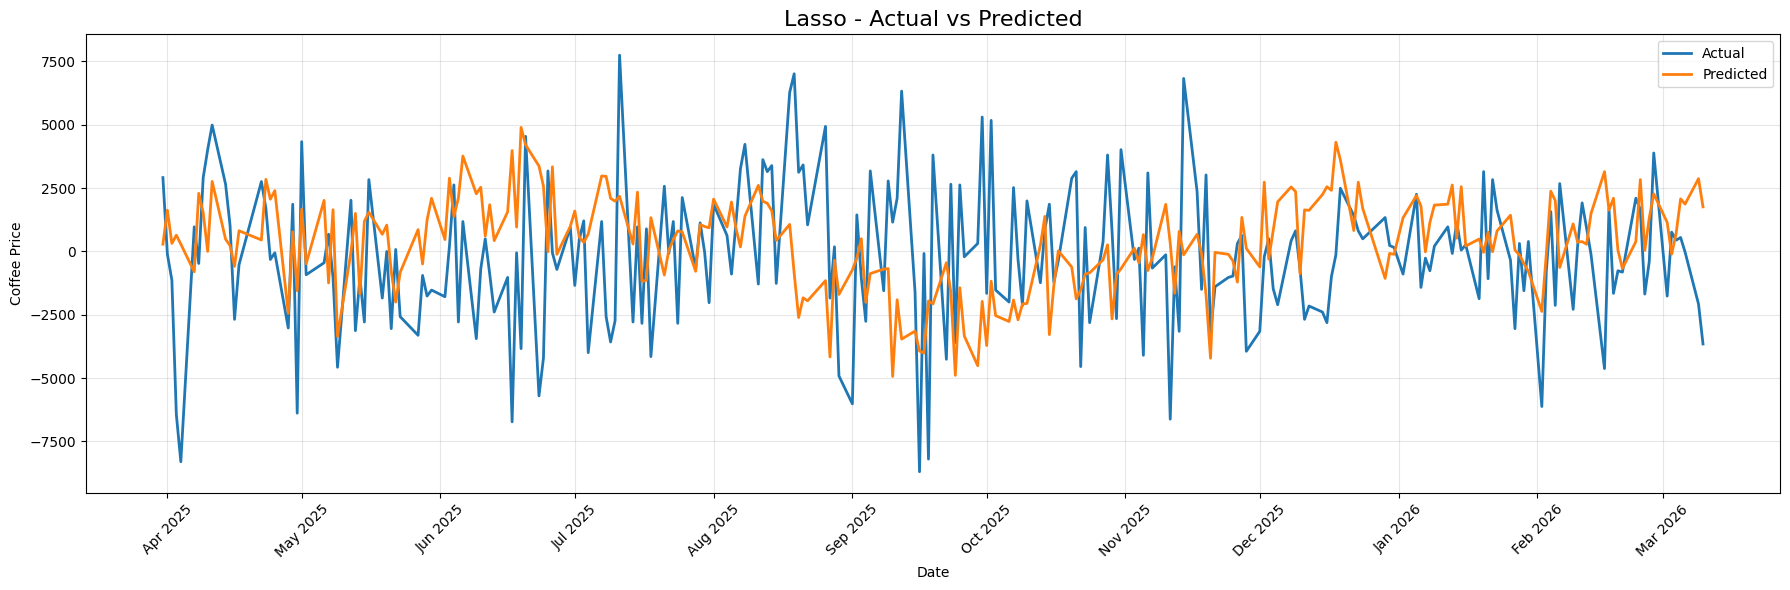

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# TEST DATES
# =========================
test_dates = df.loc[
    ~train_mask,
    "date"
].reset_index(drop=True)

# =========================
# CHECK LENGTH
# =========================
print("test_dates :", len(test_dates))
print("y_test     :", len(y_test))
print("pred_lasso :", len(pred_lasso))

# =========================
# PLOT
# =========================
plt.figure(figsize=(18, 6))

# Actual
plt.plot(
    test_dates,
    y_test.reset_index(drop=True),
    label="Actual",
    linewidth=2
)

# Predicted
plt.plot(
    test_dates,
    pred_lasso,
    label="Predicted",
    linewidth=2
)

# =========================
# DATE FORMAT
# =========================
ax = plt.gca()

# Hiện mỗi tháng
ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

# Format tháng/năm
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

# =========================
# STYLE
# =========================
plt.title(
    "Lasso - Actual vs Predicted",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [17]:
# =========================
# CELL — RIDGE REGRESSION
# =========================

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# HYPERPARAMETER GRID
# =========================
ridge_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
}

# =========================
# MODEL
# =========================
ridge_model = Ridge(
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
ridge_grid = GridSearchCV(
    estimator=ridge_model,
    param_grid=ridge_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
ridge_grid.fit(X_train_scaled, y_train)

# =========================
# BEST MODEL
# =========================
best_ridge = ridge_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save model
model_path = os.path.join(checkpoint_dir, "best_ridge.pkl")
joblib.dump(best_ridge, model_path)

# Save scaler
scaler_path = os.path.join(checkpoint_dir, "ridge_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

# =========================
# PREDICTION
# =========================
pred_ridge = best_ridge.predict(X_test_scaled)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_ridge)
mse = mean_squared_error(y_test, pred_ridge)
rmse = np.sqrt(mse)

print("Best Params:", ridge_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Model saved to: checkpoints/best_ridge.pkl
Scaler saved to: checkpoints/ridge_scaler.pkl
Best Params: {'alpha': 10.0}
MAE  : 2497.6390
MSE  : 9963689.9309
RMSE : 3156.5313


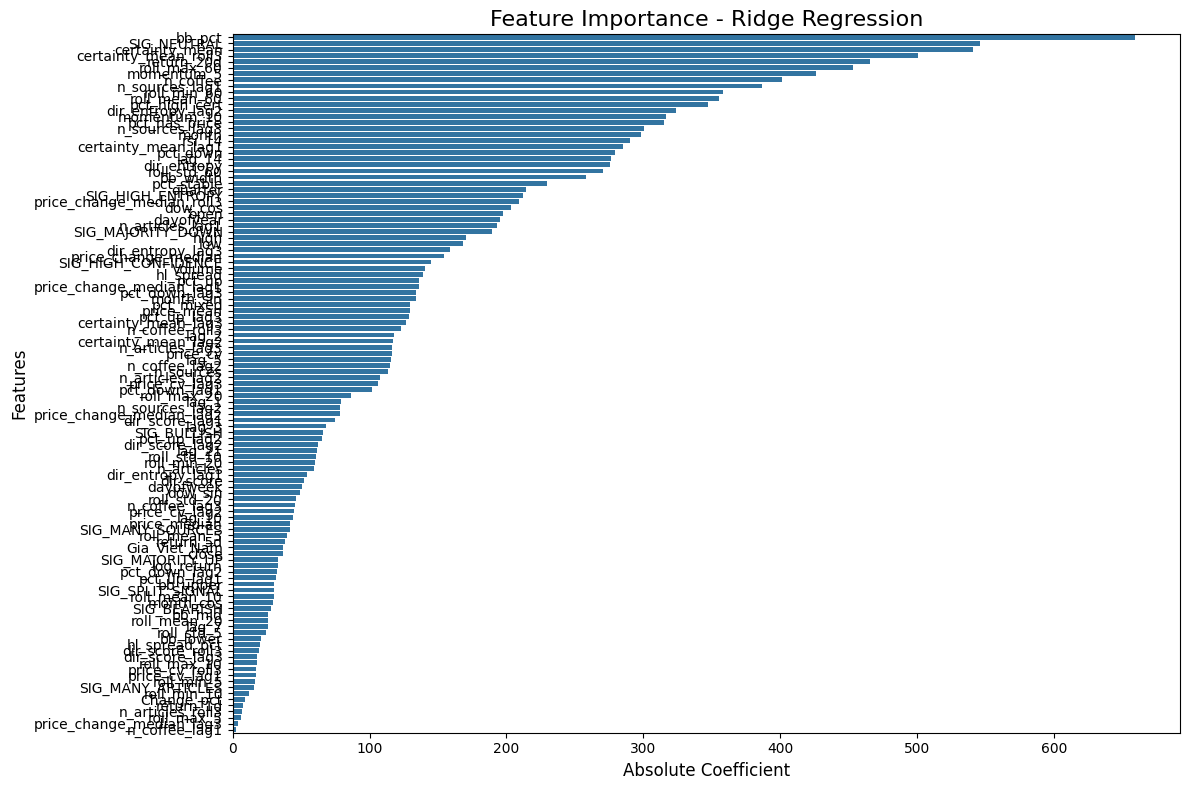

In [18]:
# =========================
# CELL — RIDGE FEATURE IMPORTANCE
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# CREATE COEFFICIENT DATAFRAME
# =========================
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_ridge.coef_
})

# =========================
# ABSOLUTE IMPORTANCE
# =========================
coef_df["Abs_Coefficient"] = np.abs(
    coef_df["Coefficient"]
)

# =========================
# SORT FEATURES
# =========================
coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

# =========================
# PLOT ALL FEATURES
# =========================
plt.figure(figsize=(12, 8))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title(
    "Feature Importance - Ridge Regression",
    fontsize=16
)

plt.xlabel("Absolute Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

test_dates : 239
y_test     : 239
pred_ridge : 239


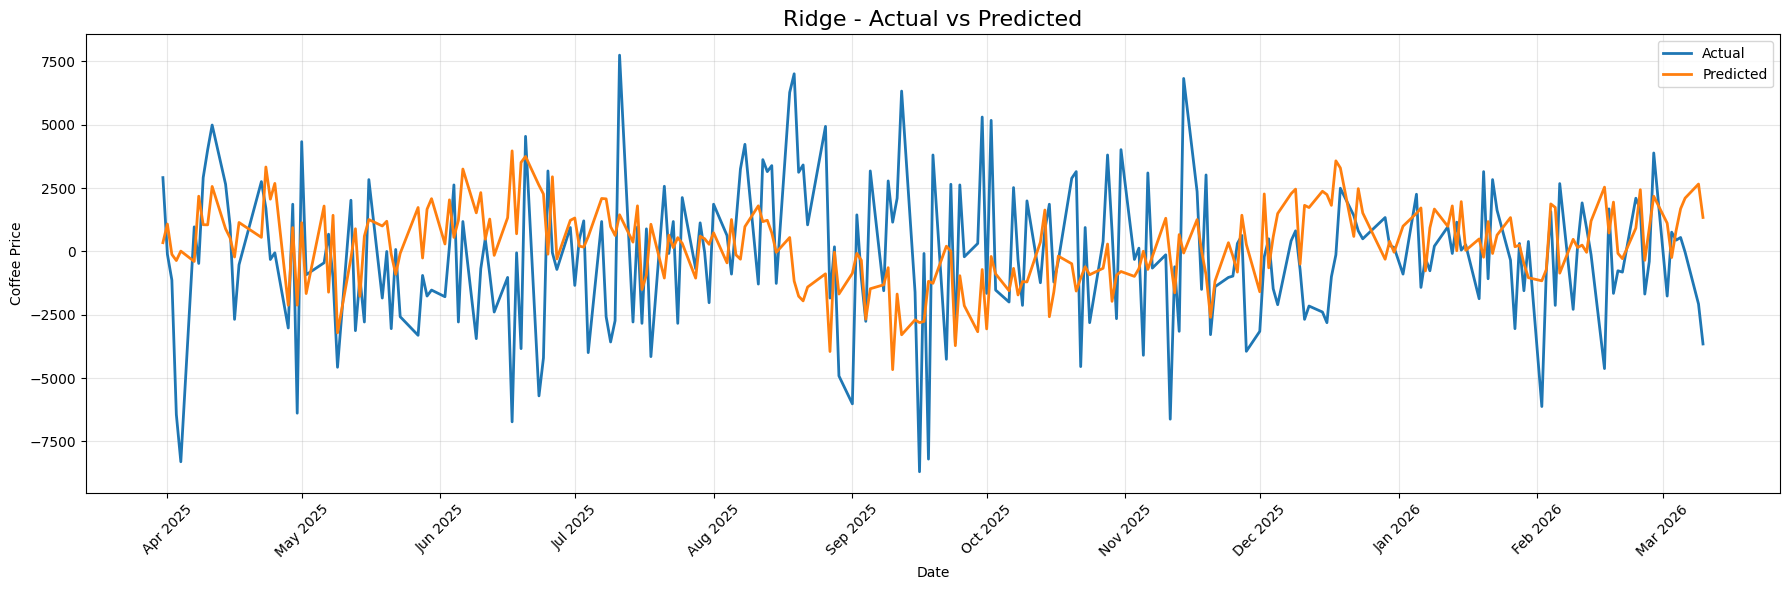

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# TEST DATES
# =========================
test_dates = df.loc[
    ~train_mask,
    "date"
].reset_index(drop=True)

# =========================
# CHECK LENGTH
# =========================
print("test_dates :", len(test_dates))
print("y_test     :", len(y_test))
print("pred_ridge :", len(pred_ridge))

# =========================
# PLOT
# =========================
plt.figure(figsize=(18, 6))

# Actual
plt.plot(
    test_dates,
    y_test.reset_index(drop=True),
    label="Actual",
    linewidth=2
)

# Predicted
plt.plot(
    test_dates,
    pred_ridge,
    label="Predicted",
    linewidth=2
)

# =========================
# DATE FORMAT
# =========================
ax = plt.gca()

# Hiện mỗi tháng
ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

# Format tháng/năm
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

# =========================
# STYLE
# =========================
plt.title(
    "Ridge - Actual vs Predicted",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [20]:
# =========================
# CELL — ELASTIC NET
# =========================

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# =========================
# HYPERPARAMETER GRID
# =========================
elastic_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "l1_ratio": [0.2, 0.5, 0.8]
}

# =========================
# MODEL
# =========================
elastic_model = ElasticNet(
    max_iter=10000,
    random_state=42
)

# =========================
# GRID SEARCH
# =========================
elastic_grid = GridSearchCV(
    estimator=elastic_model,
    param_grid=elastic_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
elastic_grid.fit(X_train_scaled, y_train)

# =========================
# BEST MODEL
# =========================
best_elastic = elastic_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save model
model_path = os.path.join(checkpoint_dir, "best_elasticnet.pkl")
joblib.dump(best_elastic, model_path)

# Save scaler
scaler_path = os.path.join(checkpoint_dir, "elasticnet_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

# =========================
# PREDICTION
# =========================
pred_elastic = best_elastic.predict(X_test_scaled)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_elastic)
mse = mean_squared_error(y_test, pred_elastic)
rmse = np.sqrt(mse)

print("Best Params:", elastic_grid.best_params_)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.126e+07, tolerance: 1.031e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.970e+07, tolerance: 2.362e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.584e+08, tolerance: 5.769e

Model saved to: checkpoints/best_elasticnet.pkl
Scaler saved to: checkpoints/elasticnet_scaler.pkl
Best Params: {'alpha': 1.0, 'l1_ratio': 0.2}
MAE  : 2172.2945
MSE  : 7950827.1258
RMSE : 2819.7211


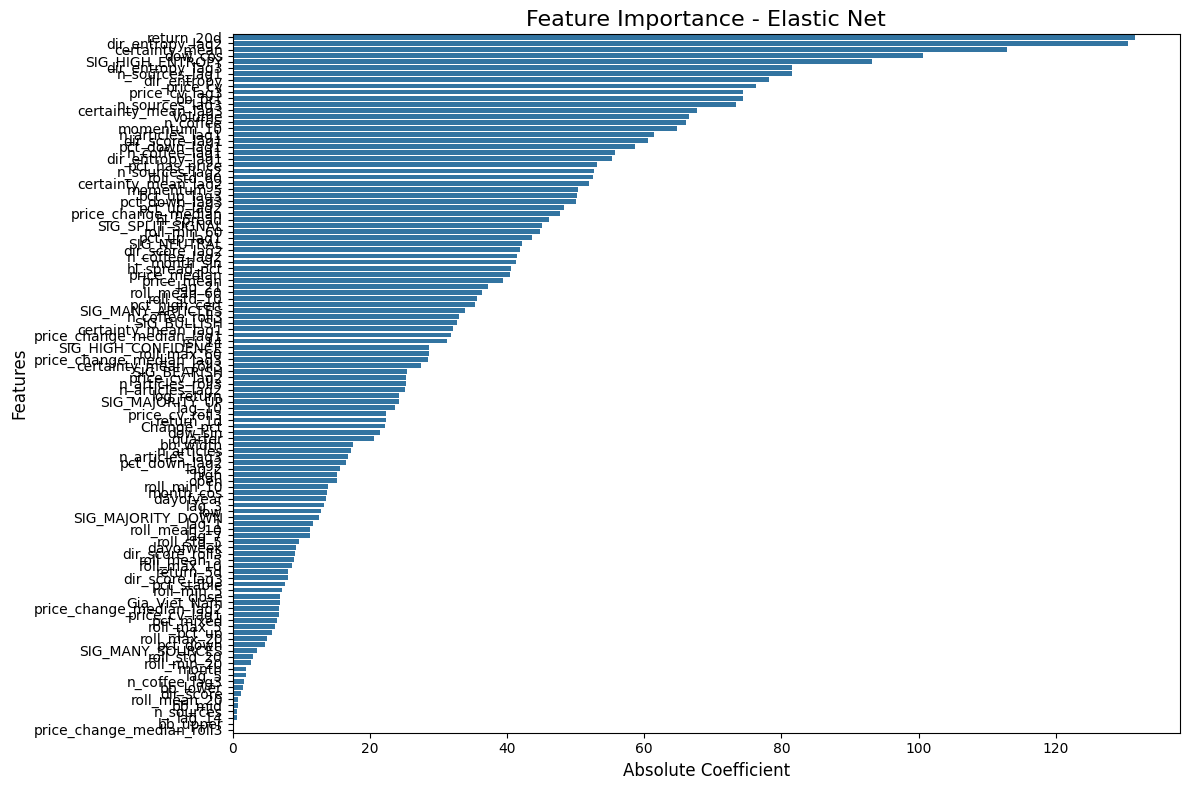

In [21]:
# =========================
# CELL — ELASTIC NET FEATURE IMPORTANCE
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# CREATE COEFFICIENT DATAFRAME
# =========================
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_elastic.coef_
})

# =========================
# ABSOLUTE IMPORTANCE
# =========================
coef_df["Abs_Coefficient"] = np.abs(
    coef_df["Coefficient"]
)

# =========================
# SORT FEATURES
# =========================
coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

# =========================
# PLOT ALL FEATURES
# =========================
plt.figure(figsize=(12, 8))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title(
    "Feature Importance - Elastic Net",
    fontsize=16
)

plt.xlabel("Absolute Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

test_dates   : 239
y_test       : 239
pred_elastic : 239


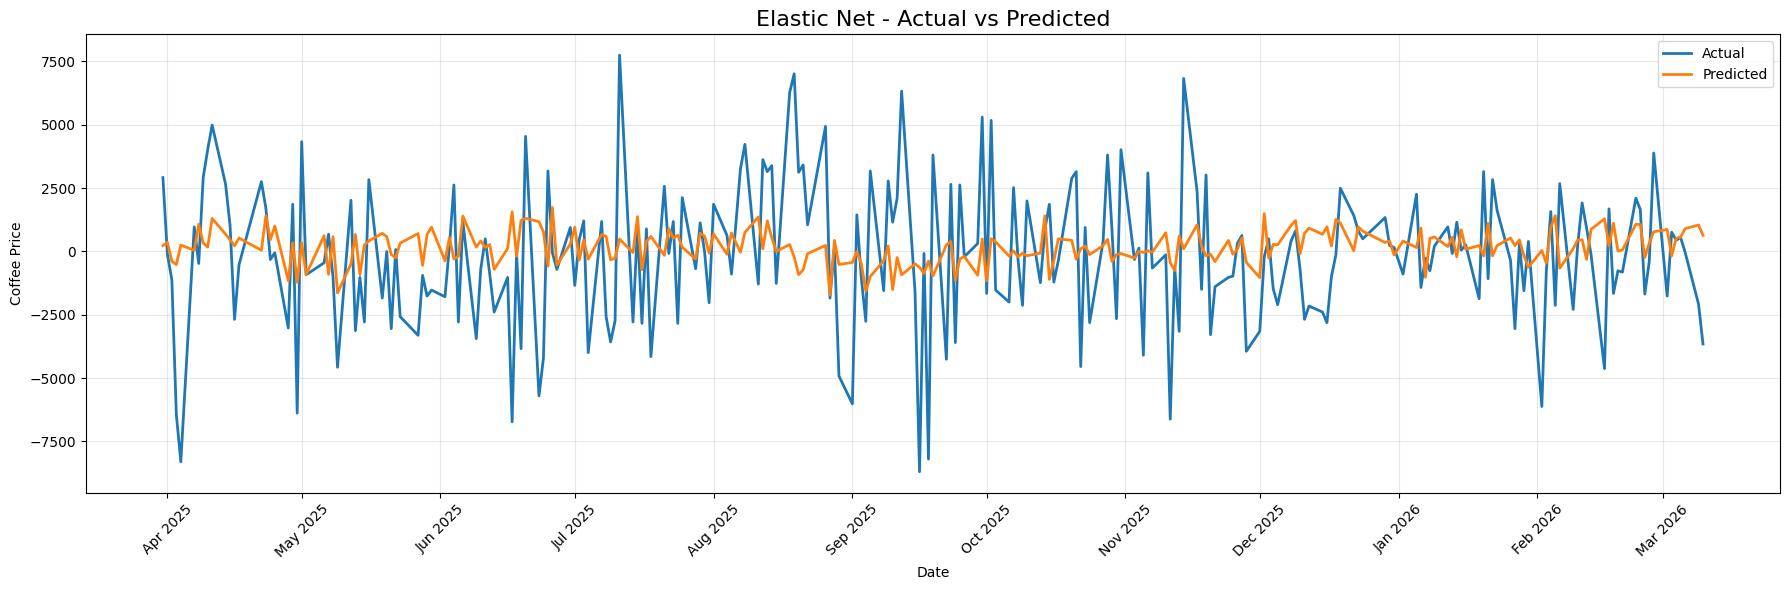

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# TEST DATES
# =========================
test_dates = df.loc[
    ~train_mask,
    "date"
].reset_index(drop=True)

# =========================
# CHECK LENGTH
# =========================
print("test_dates   :", len(test_dates))
print("y_test       :", len(y_test))
print("pred_elastic :", len(pred_elastic))

# =========================
# PLOT
# =========================
plt.figure(figsize=(18, 6))

# Actual
plt.plot(
    test_dates,
    y_test.reset_index(drop=True),
    label="Actual",
    linewidth=2
)

# Predicted
plt.plot(
    test_dates,
    pred_elastic,
    label="Predicted",
    linewidth=2
)

# =========================
# DATE FORMAT
# =========================
ax = plt.gca()

# Hiện mỗi tháng
ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

# Format tháng/năm
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

# =========================
# STYLE
# =========================
plt.title(
    "Elastic Net - Actual vs Predicted",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [23]:
# =========================
# CELL — SVM REGRESSION
# =========================

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib
import os

# =========================
# SCALE DATA
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# HYPERPARAMETER GRID
# =========================
svr_params = [
    # Linear SVM
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10, 100],
        "epsilon": [0.001, 0.01, 0.1]
    },

    # Kernel SVM (RBF)
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10, 100],
        "epsilon": [0.001, 0.01, 0.1],
        "gamma": ["scale", "auto"]
    }
]

# =========================
# MODEL
# =========================
svr_model = SVR()

# =========================
# GRID SEARCH
# =========================
svr_grid = GridSearchCV(
    estimator=svr_model,
    param_grid=svr_params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# =========================
# TRAINING
# =========================
svr_grid.fit(X_train_scaled, y_train)

# =========================
# BEST MODEL
# =========================
best_svr = svr_grid.best_estimator_

# =========================
# SAVE CHECKPOINT
# =========================
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save model
model_path = os.path.join(checkpoint_dir, "best_svr.pkl")
joblib.dump(best_svr, model_path)

# Save scaler
scaler_path = os.path.join(checkpoint_dir, "svr_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

# =========================
# PREDICTION
# =========================
pred_svr = best_svr.predict(X_test_scaled)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, pred_svr)
mse = mean_squared_error(y_test, pred_svr)
rmse = np.sqrt(mse)

print("Best Params:", svr_grid.best_params_)
print(f"Best Kernel: {best_svr.kernel}")

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model saved to: checkpoints/best_svr.pkl
Scaler saved to: checkpoints/svr_scaler.pkl
Best Params: {'C': 100, 'epsilon': 0.001, 'gamma': 'scale', 'kernel': 'rbf'}
Best Kernel: rbf
MAE  : 2156.0980
MSE  : 7857169.8981
RMSE : 2803.0644


Feature importance trực tiếp không khả dụng cho RBF SVR.
Hãy dùng permutation importance.


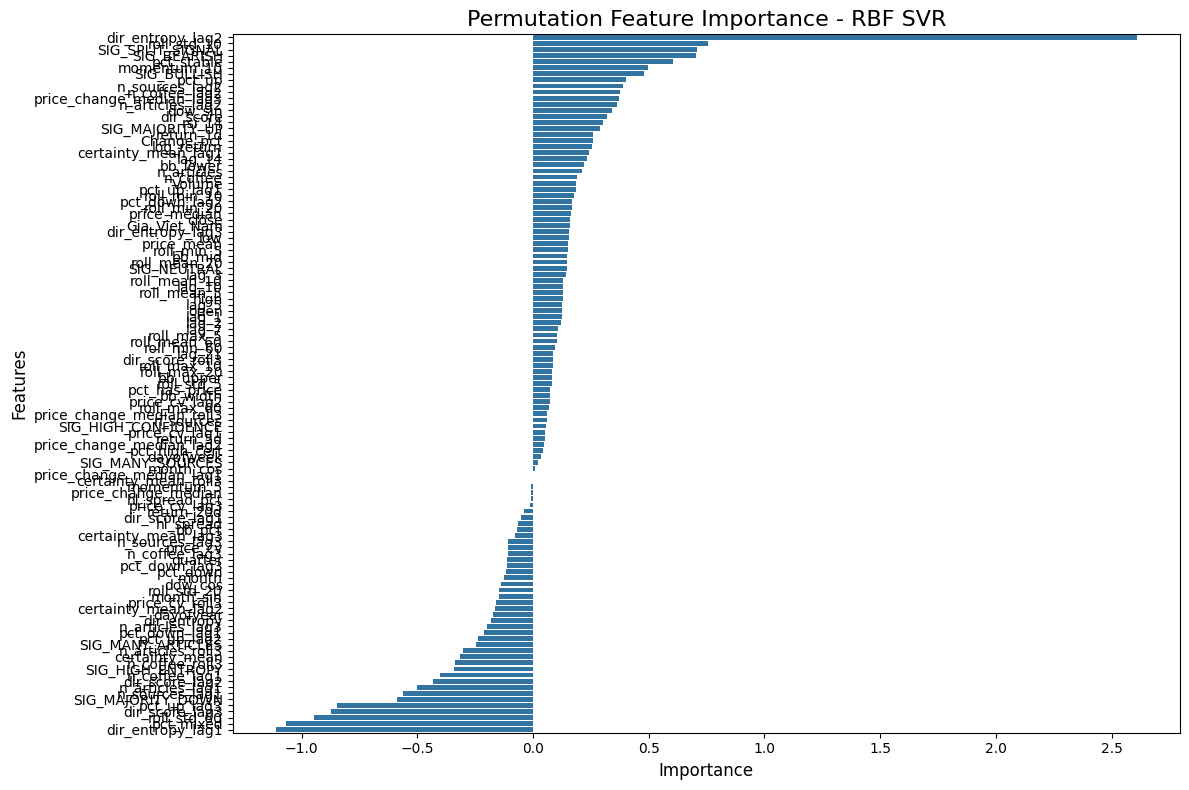

In [24]:
# =========================
# CELL — SVM FEATURE IMPORTANCE
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# CHECK KERNEL TYPE
# =========================
if best_svr.kernel == "linear":

    # =========================
    # CREATE COEFFICIENT DATAFRAME
    # =========================
    coef_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": best_svr.coef_[0]
    })

    # =========================
    # ABSOLUTE IMPORTANCE
    # =========================
    coef_df["Abs_Coefficient"] = np.abs(
        coef_df["Coefficient"]
    )

    # =========================
    # SORT FEATURES
    # =========================
    coef_df = coef_df.sort_values(
        by="Abs_Coefficient",
        ascending=False
    )

    # =========================
    # PLOT ALL FEATURES
    # =========================
    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=coef_df,
        x="Abs_Coefficient",
        y="Feature"
    )

    plt.title(
        "Feature Importance - Linear SVR",
        fontsize=16
    )

    plt.xlabel("Absolute Coefficient", fontsize=12)
    plt.ylabel("Features", fontsize=12)

    plt.tight_layout()
    plt.show()

else:

    print("Feature importance trực tiếp không khả dụng cho RBF SVR.")
    print("Hãy dùng permutation importance.")

    # =========================
    # PERMUTATION IMPORTANCE
    # =========================
    from sklearn.inspection import permutation_importance

    result = permutation_importance(
        best_svr,
        X_test_scaled,
        y_test,
        n_repeats=10,
        random_state=42,
        scoring="neg_mean_absolute_error"
    )

    # =========================
    # CREATE IMPORTANCE DATAFRAME
    # =========================
    importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": result.importances_mean
    })

    # =========================
    # SORT FEATURES
    # =========================
    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    # =========================
    # PLOT ALL FEATURES
    # =========================
    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature"
    )

    plt.title(
        "Permutation Feature Importance - RBF SVR",
        fontsize=16
    )

    plt.xlabel("Importance", fontsize=12)
    plt.ylabel("Features", fontsize=12)

    plt.tight_layout()
    plt.show()

test_dates : 239
y_test     : 239
pred_svr   : 239


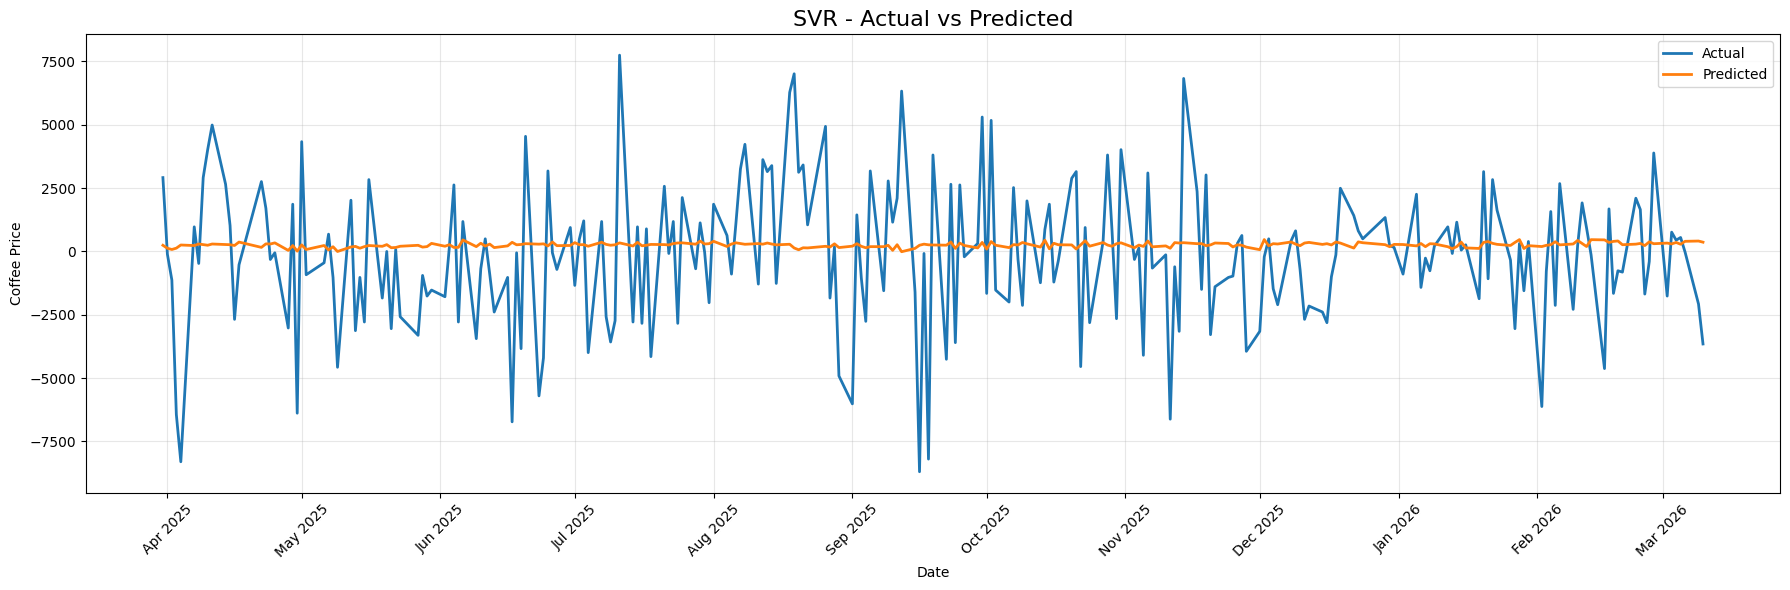

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# TEST DATES
# =========================
test_dates = df.loc[
    ~train_mask,
    "date"
].reset_index(drop=True)

# =========================
# CHECK LENGTH
# =========================
print("test_dates :", len(test_dates))
print("y_test     :", len(y_test))
print("pred_svr   :", len(pred_svr))

# =========================
# PLOT
# =========================
plt.figure(figsize=(18, 6))

# Actual
plt.plot(
    test_dates,
    y_test.reset_index(drop=True),
    label="Actual",
    linewidth=2
)

# Predicted
plt.plot(
    test_dates,
    pred_svr,
    label="Predicted",
    linewidth=2
)

# =========================
# DATE FORMAT
# =========================
ax = plt.gca()

# Hiện mỗi tháng
ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

# Format tháng/năm
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

# =========================
# STYLE
# =========================
plt.title(
    "SVR - Actual vs Predicted",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Coffee Price")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [26]:
# =========================
# CELL — SAVE ALL MODEL METRICS
# =========================

import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================
# CREATE METRICS TABLE
# =========================
metrics_df = pd.DataFrame({

    "Model": [
        "LightGBM",
        "CatBoost",
        "LASSO",
        "Ridge",
        "ElasticNet",
        "SVR"
    ],

    "MAE": [
        mean_absolute_error(y_test, pred_lgbm),
        mean_absolute_error(y_test, pred_cat),
        mean_absolute_error(y_test, pred_lasso),
        mean_absolute_error(y_test, pred_ridge),
        mean_absolute_error(y_test, pred_elastic),
        mean_absolute_error(y_test, pred_svr)
    ],

    "MSE": [
        mean_squared_error(y_test, pred_lgbm),
        mean_squared_error(y_test, pred_cat),
        mean_squared_error(y_test, pred_lasso),
        mean_squared_error(y_test, pred_ridge),
        mean_squared_error(y_test, pred_elastic),
        mean_squared_error(y_test, pred_svr)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_lgbm)),
        np.sqrt(mean_squared_error(y_test, pred_cat)),
        np.sqrt(mean_squared_error(y_test, pred_lasso)),
        np.sqrt(mean_squared_error(y_test, pred_ridge)),
        np.sqrt(mean_squared_error(y_test, pred_elastic)),
        np.sqrt(mean_squared_error(y_test, pred_svr))
    ],

    "R2 Score": [
        r2_score(y_test, pred_lgbm),
        r2_score(y_test, pred_cat),
        r2_score(y_test, pred_lasso),
        r2_score(y_test, pred_ridge),
        r2_score(y_test, pred_elastic),
        r2_score(y_test, pred_svr)
    ]
})

# =========================
# SORT BY RMSE
# =========================
metrics_df = metrics_df.sort_values(
    by="RMSE",
    ascending=True
)

# =========================
# SAVE CSV
# =========================
metrics_df.to_csv(
    "all_model_metrics.csv",
    index=False
)

# =========================
# DISPLAY
# =========================
print(metrics_df)

print("\nSaved: all_model_metrics.csv")

        Model          MAE           MSE         RMSE  R2 Score
1    CatBoost  2162.066916  7.851471e+06  2802.047674 -0.017134
5         SVR  2156.098035  7.857170e+06  2803.064376 -0.017873
4  ElasticNet  2172.294510  7.950827e+06  2819.721108 -0.030006
0    LightGBM  2205.916217  8.062394e+06  2839.435573 -0.044459
3       Ridge  2497.639013  9.963690e+06  3156.531313 -0.290766
2       LASSO  2641.788176  1.114522e+07  3338.445561 -0.443829

Saved: all_model_metrics.csv
